# C03 · Code walkthrough: the battery (`battery.py`, `battery_ecm.py`, `cells.py`)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`), so it cannot drift from the code. Each module ends with gotchas; the notebook ends with findings,
limits, what's next and review questions.

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/components/battery.py` | 65 | `Battery`: constant OCV, constant R, mass = max(energy, power); the Tier 1 model |
| `powertrain/components/battery_ecm.py` | 312 | `EquivalentCircuitBattery`: OCV(SOC) + R0 + two RC branches, series/parallel pack, ageing, power-density factor; OCV and resistance submodels; the INR21700-50G cell and its hard-coded fit coefficients |
| `powertrain/cells.py` | 169 | data layer: CSV loaders for `data/batteries/`, the OCV polynomial fit, the resistance least squares (an `asb.Opti`), pulse-power formula |

**Imports.** `battery.py` imports only `aerosandbox.numpy`. `battery_ecm.py` imports `aerosandbox` (for
`InterpolatedModel`) and nothing from the package. `cells.py` imports `battery_ecm` (the model classes and the
cell factory): data depends on the model, never the reverse ("components cannot read files", `cells.py` L9-11).

**Who imports them** (`grep`): both component modules are imported by `powertrain/ports.py`, `compatibility.py`,
`redundancy.py`, `topologies.py` (constant only), `thermal/heat.py`, `performance/flight_point.py` (ECM),
`mission/mission.py` (ECM), `trajectory/tiltrotor.py`, and the examples (`halo_sizing.py`,
`series_hybrid_point*.py`, `trajectory_optimization.py`). `cells.py` is imported only by
`tests/powertrain/test_battery_ecm.py`: the sizing never reads a CSV.

Design log: `docs/decisions/021-battery-ecm.md` (Tier 17, the ECM), `022-ecm-reference.md` (the ECM becomes the Halo
reference, payload 780 kg), `028-thermal.md` (pack thermal model), `032-redundancy.md` (strings).

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft, build_halo_battery

ref, assumptions = baseline(), baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, HaloRequirements(), assumptions)   # the sized v3.6 aircraft, in numbers
pack = aircraft.powertrain.topology.instances["battery"].component             # the sized EquivalentCircuitBattery
print(type(pack).__name__, "count_series", pack.count_series, "count_parallel", round(pack.count_parallel, 4))

EquivalentCircuitBattery count_series 210 count_parallel 22.9527


---
## 1. `powertrain/components/battery.py`: the constant battery

In [2]:
show_source("src/aircraft_closure/powertrain/components/battery.py")

# src/aircraft_closure/powertrain/components/battery.py  lines 1-65
   1  """Constant OCV/resistance battery; positive current discharges the pack."""
   2  from dataclasses import dataclass
   3  from typing import Any
   4  import aerosandbox.numpy as np
   5  
   6  
   7  @dataclass(frozen=True)
   8  class BatteryResult:
   9      voltage_V: Any
  10      current_A: Any
  11      power_electric_W: Any
  12      power_loss_W: Any
  13      power_chemical_W: Any
  14      soc_next: Any
  15  
  16  
  17  @dataclass(frozen=True)
  18  class BatteryLimits:
  19      max_discharge_power_W: Any
  20      max_charge_power_W: Any
  21      min_soc: float
  22      max_soc: float
  23  
  24  
  25  @dataclass(frozen=True)
  26  class Battery:
  27      energy_capacity_J: Any = 36000000.0
  28      voltage_open_circuit_V: Any = 800.0
  29      resistance_ohm: Any = 0.05
  30      specific_energy_J_kg: float = 900000.0
  31      specific_power_W_kg: float = 3000.0
  32      max_discharge_p

**Line by line**

- **L1** the sign convention, stated once: positive current discharges. The battery's electrical port is an OUT port
  (`powertrain/ports.py` L25-26), so positive current feeds the bus.
- **L7-14 `BatteryResult`**: terminal voltage, current, terminal power V·I, Joule loss, chemical power, next SOC.
  Fields typed `Any`: floats or CasADi expressions.
- **L17-22 `BatteryLimits`**: power ratings and the SOC window. Ratings are in **power**, not current (the ECM uses
  current).
- **L25-37 `Battery`** defaults (36 MJ = 10 kWh, 800 V, 0.05 ohm, 250 Wh/kg = 900 kJ/kg, 3 kW/kg) are placeholders
  for unit tests; the Halo always passes its own values (section 4.1).
- **L39-48 `get_mass`**: the pack must carry both its energy and its power rating:

$$m = \max\left(\frac{E}{e_{spec}},\ \frac{\max(P_{dis}, P_{chg})}{p_{spec}}\right)$$

  The max is non-smooth where the two terms cross, which is exactly where an optimizer sizing both E and P wants to
  sit. With `mass_smoothing_kg` set it becomes `np.softmax(a, b, softness=s)` = s·ln(e^(a/s) + e^(b/s)), whose worst
  error (at a = b) is s·ln 2. The Halo uses s = 10 kg (`battery_mass_smoothing_kg`), so at most 6.9 kg.
- **L50-51 `get_limits`**: repackages the ratings.
- **L53-61 `evaluate(current_A, soc, duration_s=0)`**:

$$V = V_{oc} - I R,\qquad P_{chem} = V_{oc} I,\qquad P_{loss} = I^2 R,\qquad s_1 = s_0 - \frac{V_{oc} I\, \Delta t}{E}$$

  Terminal power V·I = P_chem − P_loss exactly. SOC is depleted by **chemical** energy (L54-55 comment): using
  terminal energy would forget the I²R heat. With I < 0 (charging) SOC rises but the loss I²R stays positive. SOC is
  never clamped (L56): the caller constrains it. With `duration_s=0` (the flight point's call, section 4.3)
  `soc_next = soc`; the mission does the SOC update itself for this class (`mission.py` L124-125).
- **L64-65** a smoke test.

**Run it** on the constant pack the Halo would build with the same energy and power as the sized ECM pack (the
`battery_model="constant"` branch of `build_halo_battery`):

In [3]:
from aircraft_closure.powertrain.components.battery import Battery
design_constant = replace(ref.design, energy_capacity_battery_J=pack.energy_capacity_J,
                          power_max_discharge_battery_W=pack.power_max_discharge_W)
constant = build_halo_battery(design_constant, replace(assumptions, battery_model="constant"))
print(f"E = {constant.energy_capacity_J/3.6e6:.2f} kWh, R = {constant.resistance_ohm*1e3:.3f} mOhm "
      f"(= 1.8e6 ohm J / E), P_dis = {constant.max_discharge_power_W/1e3:.0f} kW, P_chg = {constant.max_charge_power_W/1e3:.0f} kW")
r = constant.evaluate(500.0, 0.8, 60.0)
print(r)
check("constant: V = OCV - I R", abs(r.voltage_V - (800.0 - 500.0 * constant.resistance_ohm)) < 1e-9)
check("constant: terminal = chemical - loss", abs(r.power_electric_W - (r.power_chemical_W - r.power_loss_W)) < 1e-6)
check("constant: SOC falls by chemical energy / E",
      abs((0.8 - r.soc_next) - 800.0 * 500.0 * 60.0 / constant.energy_capacity_J) < 1e-12)
charge = constant.evaluate(-200.0, 0.5, 60.0)
check("constant: charging raises SOC, loss stays positive", charge.soc_next > 0.5 and charge.power_loss_W > 0)

exact = replace(constant, mass_smoothing_kg=None).get_mass()
m_e = constant.energy_capacity_J / constant.specific_energy_J_kg
m_p = constant.max_discharge_power_W / constant.specific_power_W_kg
tie = replace(constant, max_discharge_power_W=m_e * constant.specific_power_W_kg)     # energy mass = power mass
print(f"mass: energy {m_e:.1f} kg, power {m_p:.1f} kg, exact max {exact:.1f} kg, softmax {constant.get_mass():.2f} kg")
check("softmax overshoot is at most s ln2 and reaches it where the two masses tie",
      0 <= constant.get_mass() - exact <= 10 * np.log(2) + 1e-9
      and abs(tie.get_mass() - m_e - 10 * np.log(2)) < 1e-9)

E = 69.99 kWh, R = 7.143 mOhm (= 1.8e6 ohm J / E), P_dis = 850 kW, P_chg = 425 kW
BatteryResult(voltage_V=796.42826079474, current_A=500.0, power_electric_W=398214.13039737, power_loss_W=1785.8696026299651, power_chemical_W=400000.0, soc_next=0.7047536211930686)
PASS  constant: V = OCV - I R
PASS  constant: terminal = chemical - loss
PASS  constant: SOC falls by chemical energy / E
PASS  constant: charging raises SOC, loss stays positive
mass: energy 280.0 kg, power 283.4 kg, exact max 283.4 kg, softmax 288.78 kg
PASS  softmax overshoot is at most s ln2 and reaches it where the two masses tie


**Gotchas (`battery.py`)**

- The OCV does not depend on SOC: the terminal voltage of a mission is a straight line in current only. This is the
  "weird / linear" voltage curve the author flagged, which started Tier 17 (`021`).
- `max_charge_power_W` enters the mass even though the Halo sets it to half the discharge rating, so it never
  dominates.
- The Halo resistance is R = 1.8e6 ohm·J / E: a fixed resistance-energy product (a bigger pack has more cells in
  parallel, so lower R). It is an assumption, not data.

---
## 2. `powertrain/components/battery_ecm.py`: the equivalent-circuit pack

### 2.1 Module docstring and imports

In [4]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 1, 53)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 1-53
   1  """Equivalent-circuit battery pack (Tier 17): OCV(SOC), R0 + two RC branches, series/parallel cells.
   2  
   3  Circuit per cell: OCV(SOC) in series with R0 and two RC branches (R1 || C1,
   4  R2 || C2; time constants tau_k = R_k C_k), as in Paudel et al., Batteries
   5  2025, 11, 313 (Samsung INR21700-50G). The pack is `count_series` cells in
   6  series and `count_parallel` (continuous in sizing) strings in parallel, so pack
   7  voltage = count_series x cell voltage and pack resistance = cell resistance x
   8  count_series / count_parallel. Positive current discharges.
   9  
  10  Operating relations for a constant current I over `duration_s` (dt), starting
  11  from SOC s0 and RC voltages v_k0 (pack level):
  12  
  13  * SOC (coulomb counting): s1 = s0 - I dt / Q_pack.
  14  * OCV and resistances are evaluated at the mid-interval SOC (s0 + s1) / 2, so
  15    sub-segmented missions integrate OCV

The docstring is the specification. Per cell: OCV(SOC) in series with R0 and two RC branches (R1‖C1, R2‖C2,
tau_k = R_k C_k). Pack: `count_series` cells in series, `count_parallel` strings in parallel (continuous in sizing).

- **L13 SOC by coulomb counting**: s1 = s0 − I·dt / Q_pack.
- **L14-15 mid-interval evaluation**: OCV and R at (s0 + s1)/2. The energy OCV(s_mid)·Q·Δs is the midpoint rule
  for the integral of OCV dQ, second-order accurate (checked in section 2.7).
- **L16-17 RC branch, exact for constant current.** The branch ODE is dv/dt = (I R_k − v)/tau_k, so

$$v_k(t) = I R_k + (v_{k0} - I R_k)\,e^{-t/\tau_k},\qquad \bar v_k = I R_k + (v_{k0} - I R_k)\,g_k,\quad g_k = \frac{\tau_k}{\Delta t}\left(1 - e^{-\Delta t/\tau_k}\right)$$

  No time stepping: one closed form per interval, so a 2,000 s cruise point costs the same as a 20 s hover point.
- **L18-20 terminal voltage is linear in I**: V = V* − I R_eff with

$$V^* = V_{oc} - \sum_k v_{k0}\,g_k,\qquad R_{eff} = R_0 + \sum_k R_k (1 - g_k)$$

- **L22-24 the power balance** V·I = P is the quadratic R_eff I² − V* I + P = 0. It has two roots. The physical one
  is the low-current root. V ≥ V*/2 is equivalent to I ≤ V*/(2 R_eff), i.e. the left side of the power parabola,
  and it implies P ≤ V*²/(4 R_eff) (matched load). The flight point adds it as a constraint (section 4.3).
- **L26-29** `voltage_rc_start_V=None`: the RC branches are at steady state v_k = I R_k (no memory), conservative for
  pulses shorter than about 3·tau_2.
- **L31-36 resistance form**, with x = T_ref/T − 1 (kelvin):

$$R_k(s,T) = R_{k,ref}\,e^{a x + b x^2}\left(1 + c\,e^{-(s - s_{lo})/w_{lo}} + d\,e^{(s - s_{hi})/w_{hi}}\right)$$

  then pack scaling ×count_series/count_parallel, ÷F (`factor_power_density`), ×ageing.
- **L38-43 outside the data**: OCV polynomial not clamped (missions must keep SOC in 0..1), tabulated OCV holds end
  values. The model never clips or enforces limits.
- **L45-52** imports: `cached_property` (for the B-spline table), `asb` for `InterpolatedModel`. `kelvin_offset_K`
  is module-level so `cells.py` shares the same constant.

In [5]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 55, 96)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 55-96
  55  @dataclass(frozen=True)
  56  class PolynomialOcvModel:
  57      """Cell OCV [V] = polynomial in SOC (coefficients highest power first); smooth and cheap for IPOPT."""
  58      coefficients: tuple
  59      source: str = ""
  60  
  61      def voltage_V(self, soc):
  62          voltage_V = 0 * soc + self.coefficients[0]
  63          for coefficient in self.coefficients[1:]:
  64              voltage_V = voltage_V * soc + coefficient
  65          return voltage_V
  66  
  67      def mean_voltage_V(self, soc_low=0.0, soc_high=1.0):
  68          """Mean OCV over an SOC interval (exact polynomial integral): energy = Q x mean OCV x delta SOC."""
  69          degree = len(self.coefficients) - 1
  70          antiderivative = lambda s: sum(c * s**(degree - i + 1) / (degree - i + 1)
  71                                         for i, c in enumerate(self.coefficients))
  72          return (antiderivative(so

### 2.2 OCV submodels (L55-96)

Two interchangeable classes with the same two methods (`voltage_V`, `mean_voltage_V`): duck typing, no base class.

- **L55-65 `PolynomialOcvModel`**: Horner's scheme, highest power first. **L62** `0 * soc + c0` gives the result
  the type and shape of `soc` (array, float or CasADi expression) before the loop, so even a one-coefficient
  (constant) polynomial returns an array for an array input.
- **L67-72 `mean_voltage_V`**: exact antiderivative of the polynomial. Coefficient i multiplies s^(degree − i), so
  its integral is c·s^(degree − i + 1)/(degree − i + 1). Used for the pack energy (L246). Exact, so symbolic in the
  bounds if needed.
- **L75-89 `TabulatedOcvModel`**: an `asb.InterpolatedModel` B-spline through the digitized nodes.
  `@cached_property` on a frozen dataclass works because `cached_property` writes into the instance `__dict__`
  directly (it does not go through `__setattr__`). The B-spline is built once per instance. `fill_value=None`:
  per AeroSandbox's docstring that means "attempt to extrapolate"; the CasADi B-spline in fact returns the end values
  (checked below), which is what the comment says.
- **L91-95**: trapezoid on 401 points. Numeric bounds only (`np.linspace` of an Opti variable is not defined).
- The sizing uses the polynomial (smooth and cheap); the table is offered but not used inside the sizing (plan 014
  lesson on B-splines in IPOPT, `021` "Smoothness").

In [6]:
from aircraft_closure.powertrain.components.battery_ecm import (
    PolynomialOcvModel, TabulatedOcvModel, ResistanceBranch, CellResistanceModel, LithiumIonCell,
    inr21700_50g_cell, inr21700_50g_ocv_model, inr21700_50g_resistance_model, EquivalentCircuitBattery,
    kelvin_offset_K)
from aircraft_closure.powertrain import cells

ocv = inr21700_50g_ocv_model()
soc = np.linspace(0, 1, 11)
print("OCV(SOC) [V]:", np.round(ocv.voltage_V(soc), 3))
check("Horner = numpy polyval", np.allclose(ocv.voltage_V(soc), np.polyval(ocv.coefficients, soc)))
grid = np.linspace(0.1, 0.95, 20001)
check("mean_voltage_V is the exact integral (vs fine trapezoid on 0.1..0.95)",
      abs(ocv.mean_voltage_V(0.1, 0.95) - np.sum((ocv.voltage_V(grid)[1:] + ocv.voltage_V(grid)[:-1]) / 2 * np.diff(grid)) / 0.85) < 1e-8)
print(f"mean OCV over 0..1 = {ocv.mean_voltage_V():.4f} V/cell")

table = cells.tabulated_ocv_model(30.0)
print("table outside 0..1:", table.voltage_V(np.array([-0.2, 1.2])), "end nodes:", table.voltage_open_circuit_V[0],
      table.voltage_open_circuit_V[-1])
check("tabulated OCV holds its end values outside 0..1",
      np.allclose(table.voltage_V(np.array([-0.2, 1.2])),
                  [table.voltage_open_circuit_V[0], table.voltage_open_circuit_V[-1]]))
check("table and polynomial within 25 mV on 0..1",
      np.max(np.abs(table.voltage_V(soc) - ocv.voltage_V(soc))) < 0.025)
opti = asb.Opti(); s = opti.variable(init_guess=0.5)
print("symbolic:", type(ocv.voltage_V(s)).__name__)

OCV(SOC) [V]: [2.904 3.268 3.446 3.555 3.64  3.723 3.819 3.925 4.017 4.079 4.185]
PASS  Horner = numpy polyval
PASS  mean_voltage_V is the exact integral (vs fine trapezoid on 0.1..0.95)
mean OCV over 0..1 = 3.7044 V/cell
table outside 0..1: [2.9056 4.1903] end nodes: 2.9056 4.1903
PASS  tabulated OCV holds its end values outside 0..1
PASS  table and polynomial within 25 mV on 0..1
symbolic: MX


In [7]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 98, 141)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 98-141
  98  @dataclass(frozen=True)
  99  class ResistanceBranch:
 100      """One series element: R0 (time_constant_s None) or an RC branch; cell-level values at the reference."""
 101      resistance_ref_ohm: Any
 102      time_constant_s: Any = None
 103      exponent_temperature_linear: float = 0.0
 104      exponent_temperature_quadratic: float = 0.0
 105      coefficient_soc_low: float = 0.0
 106      coefficient_soc_high: float = 0.0
 107  
 108  
 109  @dataclass(frozen=True)
 110  class CellResistanceModel:
 111      """Smooth R(SOC, T) for R0 and the RC branches (see module docstring for the form)."""
 112      branches: tuple
 113      temperature_reference_C: float = 25.0
 114      soc_low: float = 0.2
 115      soc_high: float = 0.8
 116      width_soc_low: float = 0.1
 117      width_soc_high: float = 0.05
 118      softness_soc_high: float = 0.01
 119      source: str = ""
 120  
 121      def resistance

### 2.3 Resistance submodel (L98-141)

- **L98-106 `ResistanceBranch`**: one series element. `time_constant_s=None` marks R0 (pure resistance); otherwise an
  RC branch. Exponents (a, b) for temperature; (c, d) the low- and high-SOC rise coefficients. All cell level.
- **L109-119 `CellResistanceModel`**: the branches (R0 first, by convention), the reference temperature (25 C), the
  SOC knees (0.2, 0.8: the edges of the Fig. 8 data) with their widths (fitted), and `softness_soc_high`.
- **L121-131 `resistances_ohm`**:
  - **L123** x = T_ref/T − 1 in kelvin. Positive below 25 C. A pure Arrhenius law would be ln R linear in 1/T, i.e.
    linear in x; the quadratic term b·x² was added because Arrhenius failed (45 C was no better than 30 C, `021`
    "Model form chosen").
  - **L124** low-SOC term e^(−(s − 0.2)/w_lo): equals 1 at s = 0.2, grows below. It is not limited: towards empty
    resistance keeps rising (conservative).
  - **L125-127** high-SOC term: `np.softmin(s, 0.8, softness=0.01)` replaces s by about min(s, 0.8), so above 0.8 the
    term is **held** at about 1 instead of growing. Without it R2 extrapolated ×7.6 at SOC 0.95 (take-off), `021`.
  - **L128-131** one product per branch; a tuple (R0, R1, R2). The SOC and temperature factors are shared shapes;
    each branch has its own coefficients.
- **L133-134 `time_constants_s`**: skips branch 0 (R0). Relies on R0 being first.
- **L136-140 `resistance_dc_ohm`**: the DCIR a constant-current pulse of length t measures from rest:
  R0 + Σ R_k (1 − e^(−t/tau_k)). This is what the paper tabulates (Fig. 8), so it is the function the fit matches
  (section 3.3). OCV drift is excluded here and removed from the data instead.

In [8]:
rm = inr21700_50g_resistance_model()
for s_ in (0.1, 0.2, 0.5, 0.8, 0.95):
    print(f"SOC {s_:.2f}: R0, R1, R2 = " + ", ".join(f"{r*1e3:.2f}" for r in rm.resistances_ohm(s_, 25.0)) + " mOhm")
r08, r095 = rm.resistances_ohm(0.8, 25.0)[2], rm.resistances_ohm(0.95, 25.0)[2]
check("high-SOC term held above 0.8 (R2 at 0.95 within 5 % of 0.8)", abs(r095 / r08 - 1) < 0.05)
check("low-SOC rise continues below 0.2 (R2 at 0.1 > 2 x R2 at 0.5)",
      rm.resistances_ohm(0.1, 25.0)[2] > 2 * rm.resistances_ohm(0.5, 25.0)[2])
check("cold raises R0 (0 C vs 25 C)", rm.resistances_ohm(0.5, 0.0)[0] > 1.5 * rm.resistances_ohm(0.5, 25.0)[0])
check("at T_ref, mid SOC: R_k close to R_k,ref (SOC terms small)",
      all(abs(r / b.resistance_ref_ohm - 1) < 0.1 for r, b in zip(rm.resistances_ohm(0.5, 25.0), rm.branches)))
check("DCIR of a long pulse tends to R0 + R1 + R2",
      abs(rm.resistance_dc_ohm(0.5, 25.0, 1e5) - sum(rm.resistances_ohm(0.5, 25.0))) < 1e-12)
print("DCIR at 25 C, SOC 0.5 for 2/10/30/180 s pulses [mOhm]:",
      [round(float(rm.resistance_dc_ohm(0.5, 25.0, t)) * 1e3, 2) for t in (2, 10, 30, 180)])

SOC 0.10: R0, R1, R2 = 26.77, 1.79, 58.80 mOhm
SOC 0.20: R0, R1, R2 = 24.91, 1.79, 30.68 mOhm
SOC 0.50: R0, R1, R2 = 23.97, 1.79, 16.38 mOhm
SOC 0.80: R0, R1, R2 = 24.72, 1.79, 19.32 mOhm
SOC 0.95: R0, R1, R2 = 24.86, 1.79, 19.96 mOhm
PASS  high-SOC term held above 0.8 (R2 at 0.95 within 5 % of 0.8)
PASS  low-SOC rise continues below 0.2 (R2 at 0.1 > 2 x R2 at 0.5)
PASS  cold raises R0 (0 C vs 25 C)
PASS  at T_ref, mid SOC: R_k close to R_k,ref (SOC terms small)
PASS  DCIR of a long pulse tends to R0 + R1 + R2
DCIR at 25 C, SOC 0.5 for 2/10/30/180 s pulses [mOhm]: [25.11, 28.64, 33.94, 41.88]


In [9]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 143, 217)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 143-217
 143  @dataclass(frozen=True)
 144  class LithiumIonCell:
 145      """Cell data (rated values from the datasheet table) plus OCV and resistance submodels."""
 146      capacity_As: float
 147      mass_kg: float
 148      voltage_nominal_V: float
 149      voltage_max_V: float
 150      voltage_min_V: float
 151      current_max_discharge_A: float
 152      current_max_charge_A: float
 153      ocv_model: Any
 154      resistance_model: Any
 155      source: str = ""
 156  
 157  
 158  def inr21700_50g_ocv_model():
 159      """Degree-7 least-squares polynomial through the 21 digitized 30 C OCV points (Fig. 7, Paudel et al. 2025);
 160      rms 9 mV, max 21 mV, monotonic on 0..1 (`cells.fit_ocv_polynomial`)."""
 161      return PolynomialOcvModel(coefficients=(
 162          49.61180607503143, -166.02992448421182, 226.02487919114515, -167.11922685349367, 77.10718563734386,
 163          -23.702004925522193, 5.

### 2.4 The cell, the hard-coded fits, the result types (L143-217)

- **L143-155 `LithiumIonCell`**: datasheet values (capacity in A·s, mass, nominal/max/min voltage, current ratings)
  plus the two submodels.
- **L158-164 `inr21700_50g_ocv_model`**: degree-7 coefficients, highest power first. The docstring states rms 9 mV,
  max 21 mV, monotonic on 0..1. They are literals because components cannot read files; `cells.fit_ocv_polynomial`
  regenerates them (section 3.2).
- **L167-179 `inr21700_50g_resistance_model`**: the 13 fitted numbers. Note L175: R1 carries **R0's** temperature
  exponents (3.727, 38.83) and no SOC terms. Time constants 8 s and 43 s are fixed, not fitted.
- **L182-189 `inr21700_50g_cell`**: 4.9 Ah = 17,640 A·s, 69 g, 3.6/4.2/2.5 V, 9.8 A (2C) discharge. The 4.9 A charge
  rating is an assumption (docstring).
- **L192-206 `EquivalentCircuitBatteryResult`**: the constant battery's six fields plus seven diagnostics. Only
  `voltage_V`, `current_A`, `power_electric_W`, `power_loss_W`, `power_chemical_W`, `soc_next`, `voltage_rc_end_V`,
  `voltage_end_V`, `voltage_driving_V`, `voltage_open_circuit_V` are read by production code; `power_max_W`,
  `resistance_effective_ohm` and `voltage_rc_V` are read by tests only.
- **L209-216 limits**: voltage window and **current** ratings (not power), SOC window.

In [10]:
cell = inr21700_50g_cell()
print(f"cell: {cell.capacity_As/3600} Ah, {cell.mass_kg*1e3:.0f} g, {cell.voltage_min_V}-{cell.voltage_max_V} V, "
      f"{cell.current_max_discharge_A} A = {cell.current_max_discharge_A/(cell.capacity_As/3600):.0f}C discharge")
energy_cell_Wh = cell.capacity_As * ocv.mean_voltage_V() / 3600
print(f"cell energy (0..1 at OCV) {energy_cell_Wh:.2f} Wh -> {energy_cell_Wh/cell.mass_kg:.0f} Wh/kg cell, "
      f"{energy_cell_Wh/cell.mass_kg*0.7:.0f} Wh/kg pack (x0.7), {energy_cell_Wh/cell.mass_kg*0.7*0.8:.0f} Wh/kg at 80 % EOL")
check("pack specific energy at end of life about 147 Wh/kg (021)",
      abs(energy_cell_Wh / cell.mass_kg * 0.7 * 0.8 - 147) < 2)
check("OCV monotonic on 0..1", np.all(np.diff(ocv.voltage_V(np.linspace(0, 1, 501))) > 0))
check("OCV rises 26 % from SOC 0.10 to 0.95", abs(ocv.voltage_V(0.95) / ocv.voltage_V(0.10) - 1.26) < 0.005)

cell: 4.9 Ah, 69 g, 2.5-4.2 V, 9.8 A = 2C discharge
cell energy (0..1 at OCV) 18.15 Wh -> 263 Wh/kg cell, 184 Wh/kg pack (x0.7), 147 Wh/kg at 80 % EOL
PASS  pack specific energy at end of life about 147 Wh/kg (021)
PASS  OCV monotonic on 0..1
PASS  OCV rises 26 % from SOC 0.10 to 0.95


In [11]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 219, 271)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 219-271
 219  @dataclass(frozen=True)
 220  class EquivalentCircuitBattery:
 221      count_series: Any = 210
 222      count_parallel: Any = 20.0
 223      cell: Any = field(default_factory=inr21700_50g_cell)
 224      factor_power_density: Any = 1.0         # resistances / factor, current rating x factor (1 = the 50G)
 225      temperature_cell_C: Any = 25.0
 226      factor_capacity_ageing: Any = 1.0       # remaining capacity fraction (end of life e.g. 0.8)
 227      factor_resistance_ageing: Any = 1.0     # resistance growth (end of life e.g. 1.5)
 228      fraction_mass_cells: float = 0.7        # cell mass / pack mass (assumed, cylindrical-cell packs ~0.65-0.75)
 229      min_soc: float = 0.1
 230      max_soc: float = 0.95
 231      # Tier 19: LumpedThermalModel or None. The pack temperature is reported and limited; it does not yet feed
 232      # back into `temperature_cell_C` (the resistance stays at the mana

### 2.5 The pack: sizing properties (L219-271)

- **L220-233 fields.** `count_series` is a Python int in the Halo (structure: it sets the bus voltage window);
  `count_parallel` is the **sizing variable** (an Opti variable, continuous, `halo_sizing.py` L1125-1126).
  F = `factor_power_density`: the author's decision 2026-10-02 to keep the 50G *shape* but scale its power (`021`).
  Ageing factors default to 1 (beginning of life); the Halo passes 0.8 and 1.5. L231-233: the thermal model reports
  the pack temperature but does not feed `temperature_cell_C` (plan 028).
- **L235-237** cell count = series × parallel (non-integer in sizing).
- **L239-241 capacity** Q = parallel × cell capacity × capacity ageing. The SOC base: SOC 1 is the *aged* full charge.
- **L243-246 energy** = Q × count_series × mean OCV(0..1). Full 0..1 window at open circuit: the usable energy is
  smaller (SOC window, losses).
- **L248-251 rated power** = discharge current rating × count_series × 3.6 V nominal. Used for sizing the electrical
  layer (feeder, DC/DC) in `halo_sizing.py` L521-526, and as `design.power_max_discharge_battery_W`.
- **L253-254 pack OCV** = count_series × cell OCV.
- **L256-260 pack resistances**: series adds, parallel divides, ageing multiplies, F divides:

$$R_{pack} = R_{cell}\,\frac{N_s}{N_p}\,\frac{k_{age}}{F}$$

  L258: `temperature_C=None` falls back to the pack's managed temperature (25 C in the Halo).
- **L262-263 mass** = cells × 69 g / 0.7. No power term: F changes power without changing mass (`021`).
- **L265-271 limits**: voltage window = N_s × cell window (210 × 2.5..4.2 = 525..882 V); current ratings =
  N_p × cell rating × F (F scales current as it scales conductance, so the C-rate rating goes 2C → 10C at F = 5).

In [12]:
lim = pack.get_limits()
print(f"sized pack: {pack.count_cells:.0f} cells, {pack.get_mass():.1f} kg, Q = {pack.capacity_As/3600:.2f} Ah, "
      f"E = {pack.energy_capacity_J/3.6e6:.2f} kWh, P_rated = {pack.power_max_discharge_W/1e3:.0f} kW")
print(lim)
check("pack energy = design.energy_capacity_battery_J of the baseline",
      abs(pack.energy_capacity_J / ref.design.energy_capacity_battery_J - 1) < 1e-12)
check("pack energy = result.energy_battery_kWh", abs(pack.energy_capacity_J / 3.6e6 - ref.energy_battery_kWh) < 1e-9)
check("mass = cells x 69 g / 0.7 and matches the result's component mass",
      abs(pack.get_mass() - pack.count_cells * 0.069 / 0.7) < 1e-9
      and abs(pack.get_mass() - dict(ref.powertrain_masses_kg)["battery"]) < 1e-6)
check("voltage window 525-882 V", (lim.min_voltage_V, lim.max_voltage_V) == (525.0, 882.0))
check("discharge rating = 10C at F = 5", abs(lim.max_discharge_current_A / (pack.capacity_As / 3600 / 0.8) - 10) < 1e-9)
r_cell = inr21700_50g_resistance_model().resistances_ohm(0.5, 25.0)
check("pack R = cell R x Ns/Np x 1.5 / 5",
      np.allclose(pack.resistances_ohm(0.5), [r * 210 / pack.count_parallel * 1.5 / 5 for r in r_cell]))

sized pack: 4820 cells, 475.1 kg, Q = 89.97 Ah, E = 69.99 kWh, P_rated = 850 kW
EquivalentCircuitBatteryLimits(min_voltage_V=525.0, max_voltage_V=882.0, max_discharge_current_A=1124.6814011828515, max_charge_current_A=562.3407005914257, min_soc=0.1, max_soc=0.95)
PASS  pack energy = design.energy_capacity_battery_J of the baseline
PASS  pack energy = result.energy_battery_kWh
PASS  mass = cells x 69 g / 0.7 and matches the result's component mass
PASS  voltage window 525-882 V
PASS  discharge rating = 10C at F = 5
PASS  pack R = cell R x Ns/Np x 1.5 / 5


**Cell specific power implied by F (`021` table, F = 1 column).** Four measures at beginning of life, 25 C,
SOC 0.5, per kg of cell: matched load OCV²/(4 ΣR); DOE pulse (Paudel eq. 12) 2.5 V·(OCV − 2.5 V)/R_dc at 10 s and at
steady state (ΣR); the current rating 9.8 A × 3.6 V. All scale linearly with F.

In [13]:
one = EquivalentCircuitBattery(count_series=1, count_parallel=1.0)       # F = 1: the 50G itself
v = one.voltage_open_circuit_V(0.5); r_sum = sum(one.resistances_ohm(0.5))
measures = {"matched load": v**2 / (4 * r_sum),
            "DOE 10 s pulse": cells.pulse_power_W(v, one.cell.resistance_model.resistance_dc_ohm(0.5, 25.0, 10.0)),
            "DOE steady": cells.pulse_power_W(v, r_sum),
            "current rating": 9.8 * 3.6}
table_021 = {"matched load": 1.19, "DOE 10 s pulse": 1.55, "DOE steady": 1.05, "current rating": 0.51}
for k, p in measures.items():
    print(f"{k:<15} F=1 {p/0.069/1e3:.2f} kW/kg   F=5 {5*p/0.069/1e3:.1f} kW/kg   (021: {table_021[k]})")
check("021 specific-power table reproduced to 1 %",
      all(abs(measures[k] / 0.069 / 1e3 / table_021[k] - 1) < 0.01 for k in measures))

matched load    F=1 1.19 kW/kg   F=5 6.0 kW/kg   (021: 1.19)
DOE 10 s pulse  F=1 1.55 kW/kg   F=5 7.7 kW/kg   (021: 1.55)
DOE steady      F=1 1.05 kW/kg   F=5 5.3 kW/kg   (021: 1.05)
current rating  F=1 0.51 kW/kg   F=5 2.6 kW/kg   (021: 0.51)
PASS  021 specific-power table reproduced to 1 %


In [14]:
show_source("src/aircraft_closure/powertrain/components/battery_ecm.py", 273, 312)

# src/aircraft_closure/powertrain/components/battery_ecm.py  lines 273-312
 273      def evaluate(self, current_A, soc, duration_s=0.0, voltage_rc_start_V=None, temperature_C=None):
 274          soc_next = soc - current_A * duration_s / self.capacity_As
 275          soc_mid = (soc + soc_next) / 2
 276          voltage_open_circuit_V = self.voltage_open_circuit_V(soc_mid)
 277          resistance_0_ohm, *resistances_rc_ohm = self.resistances_ohm(soc_mid, temperature_C)
 278          time_constants_s = self.cell.resistance_model.time_constants_s()
 279          is_instant = isinstance(duration_s, (int, float)) and duration_s == 0
 280          voltage_rc_V, voltage_rc_end_V, offsets_V, slopes_ohm = [], [], [], []
 281          for k, (r_ohm, tau_s) in enumerate(zip(resistances_rc_ohm, time_constants_s)):
 282              steady_V = current_A * r_ohm
 283              if voltage_rc_start_V is None:
 284                  # No history: polarization fully developed (steady state).
 285   

### 2.6 `evaluate` (L273-307)

- **L274** coulomb counting: s1 = s0 − I·dt/Q. Exact for constant current, any sign.
- **L275-277** OCV and the three resistances at the **mid-interval** SOC. Mid-SOC depends on I, so OCV and R are
  functions of the current variable: the "linear in I" of the docstring is linear at fixed coefficients only.
- **L278** tau_1, tau_2 = 8, 43 s from the cell model.
- **L279 `is_instant`**: a numeric zero duration (int or float; numpy float64 is a float). Python branching only on
  numbers: a symbolic duration (the cruise duration is distance / speed variable) always takes the general branch.
- **L280-294** the loop builds, per RC branch, the steady value I·R_k (L282) and three fractions:

  | case | mean fraction g | end fraction e | start v_k0 |
  |---|---|---|---|
  | L283-285 no history (`None`) | 0 | 0 | 0 |
  | L286-287 instant (dt = 0) | 1 | 1 | given |
  | L288-290 general | (tau/dt)(1 − e^(−dt/tau)) | e^(−dt/tau) | given |

  With g = e = 0 the branch sits at steady state I·R_k. With g = e = 1 it keeps its start voltage (no time to move).
- **L291-292** mean and end branch voltages: steady + (start − steady)·fraction.
- **L293-294** the decomposition of the mean voltage into an I-independent offset v_k0·g_k and a slope R_k(1 − g_k).
  Check: steady + (start − steady)·g = start·g + I·R_k(1 − g). Same thing, regrouped.
- **L295-297** V* = OCV − Σ offsets; R_eff = R0 + Σ slopes; V = V* − I·R_eff (interval-mean terminal voltage, the bus
  voltage at the point).
- **L298 end voltage** = OCV(s_mid) − Σ v_k,end − I·R0(s_mid). The value at the end of the interval used for the
  minimum-voltage margin. It uses OCV and R0 at the **mid** SOC, not the end SOC (see Findings).
- **L299-300** chemical = OCV·I; terminal = V·I; **L303** loss = chemical − terminal (R0 plus RC losses, including
  the energy charging the RC capacitors).
- **L307** P_max = V*²/(4 R_eff), the vertex of the power parabola.
- **L310-312** smoke test.

In [15]:
row = ref.engine_out_trace[0]          # engine-out hover 1/3 of the sized aircraft: ~991 A, 20 s, from SOC 0.30
res = pack.evaluate(row["current_A"], row["soc_start"], row["duration_s"], None)
I = row["current_A"]
print(f"I = {I:.1f} A, OCV = {res.voltage_open_circuit_V:.1f} V, V* = {res.voltage_driving_V:.1f} V, "
      f"R_eff = {res.resistance_effective_ohm*1e3:.1f} mOhm, V = {res.voltage_V:.1f} V, P = {res.power_electric_W/1e3:.0f} kW, "
      f"P_max = {res.power_max_W/1e3:.0f} kW, loss = {res.power_loss_W/1e3:.0f} kW")
check("V = V* - I R_eff", abs(res.voltage_V - (res.voltage_driving_V - I * res.resistance_effective_ohm)) < 1e-9)
check("no history: V* = OCV and R_eff = R0 + R1 + R2",
      abs(res.voltage_driving_V - res.voltage_open_circuit_V) < 1e-12
      and abs(res.resistance_effective_ohm - sum(pack.resistances_ohm((row["soc_start"] + res.soc_next) / 2))) < 1e-12)
check("loss = chemical - terminal", abs(res.power_loss_W - (res.power_chemical_W - res.power_electric_W)) < 1e-6)
at_soc = pack.evaluate(I, row["soc_start"], 0.0, None)          # dt = 0: SOC fixed, so the parabola is exact
vertex = pack.evaluate(at_soc.voltage_driving_V / (2 * at_soc.resistance_effective_ohm), row["soc_start"], 0.0, None)
check("P_max = V*^2/(4 R_eff) is the power at I = V*/(2 R_eff), where V = V*/2",
      abs(vertex.power_electric_W / at_soc.power_max_W - 1) < 1e-12
      and abs(vertex.voltage_V / vertex.voltage_driving_V - 0.5) < 1e-12)

# RC transient: from rest, an instant step, a long hold, and exact propagation in two halves vs one interval.
rest = (0.0, 0.0)
instant = pack.evaluate(500.0, 0.6, 0.0, rest)
check("instant step from rest: only R0 acts", abs(instant.voltage_V - (instant.voltage_open_circuit_V
                                                                     - 500.0 * pack.resistances_ohm(0.6)[0])) < 1e-9)
long = pack.evaluate(1e-3, 0.6, 1e6, rest)         # tiny current, very long: RC end -> I R_k
check("long hold: RC branches reach I R_k", np.allclose(long.voltage_rc_end_V,
                                                        [1e-3 * r for r in pack.resistances_ohm((0.6 + long.soc_next) / 2)[1:]]))
frozen = replace(pack, factor_capacity_ageing=1e9)  # huge capacity: SOC does not move, so propagation is exact
one_step = frozen.evaluate(500.0, 0.6, 60.0, rest)
half = frozen.evaluate(500.0, 0.6, 30.0, rest)
two_step = frozen.evaluate(500.0, 0.6, 30.0, half.voltage_rc_end_V)
check("RC propagation is exact: 2 x 30 s = 60 s", np.allclose(one_step.voltage_rc_end_V, two_step.voltage_rc_end_V))
check("interval means compose: mean(60) = average of the two 30 s means",
      abs(one_step.voltage_V - (half.voltage_V + two_step.voltage_V) / 2) < 1e-6)

I = 990.8 A, OCV = 740.3 V, V* = 740.3 V, R_eff = 134.7 mOhm, V = 606.8 V, P = 601 kW, P_max = 1017 kW, loss = 132 kW
PASS  V = V* - I R_eff
PASS  no history: V* = OCV and R_eff = R0 + R1 + R2
PASS  loss = chemical - terminal
PASS  P_max = V*^2/(4 R_eff) is the power at I = V*/(2 R_eff), where V = V*/2
PASS  instant step from rest: only R0 acts
PASS  long hold: RC branches reach I R_k
PASS  RC propagation is exact: 2 x 30 s = 60 s
PASS  interval means compose: mean(60) = average of the two 30 s means


### 2.7 Coulomb counting and the midpoint energy

Chemical energy per point = OCV(s_mid)·I·dt = N_s·Q·OCV_cell(s_mid)·Δs. The exact energy is N_s·Q times the
integral of OCV_cell over the SOC interval. Midpoint error is O(Δs³) per interval; with sub-segments it falls by about
4× per halving of Δs once the points are fine enough (second order overall). One point over the whole window happens
to be small by cancellation (the OCV curve changes curvature). Below on a discharge of the whole window and on the
mission's largest SOC step:

In [16]:
def energy_error(soc0, soc1, n):
    # n equal points from soc0 to soc1 at constant current, midpoint OCV per point, vs the exact OCV integral.
    edges = np.linspace(soc0, soc1, n + 1); mids = (edges[1:] + edges[:-1]) / 2
    midpoint = np.sum(ocv.voltage_V(mids) * (edges[:-1] - edges[1:]))
    exact = ocv.mean_voltage_V(soc1, soc0) * (soc0 - soc1)
    return midpoint / exact - 1
for n in (1, 2, 4, 8):
    print(f"SOC 0.95 -> 0.10 in {n} point(s): energy error {energy_error(0.95, 0.10, n)*100:+.4f} %")
check("midpoint energy is second order (4 -> 8 points: error / 4, +-20 %)",
      abs(energy_error(0.95, 0.10, 4) / energy_error(0.95, 0.10, 8) - 4) < 0.8)
cruise = ref.battery_trace[5]   # cruise 4/4, the largest SOC step of the mission
print(f"cruise 4/4: SOC {cruise['soc_start']:.3f} -> {cruise['soc_end']:.3f}, "
      f"error {energy_error(cruise['soc_start'], cruise['soc_end'], 1)*100:+.4f} %")

SOC 0.95 -> 0.10 in 1 point(s): energy error -0.0720 %
SOC 0.95 -> 0.10 in 2 point(s): energy error +0.4307 %
SOC 0.95 -> 0.10 in 4 point(s): energy error +0.0942 %
SOC 0.95 -> 0.10 in 8 point(s): energy error +0.0221 %
PASS  midpoint energy is second order (4 -> 8 points: error / 4, +-20 %)
cruise 4/4: SOC 0.658 -> 0.471, error -0.0549 %


**Plot: the sized pack's discharge curves.** Terminal voltage vs SOC at constant current, no history (steady
polarization), 25 C, end of life. The curvature comes from the OCV polynomial and the low-SOC resistance rise; the
dashed line is the 525 V minimum.

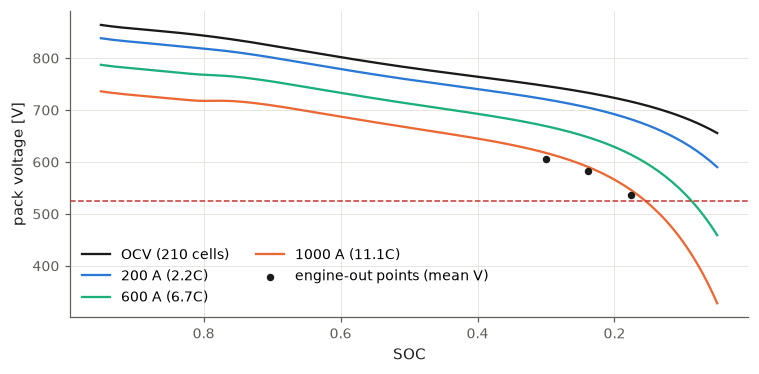

In [17]:
soc_grid = np.linspace(0.05, 0.95, 181)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(soc_grid, pack.voltage_open_circuit_V(soc_grid), color=ink, label="OCV (210 cells)")
for current_A, color in ((200.0, blue), (600.0, aqua), (1000.0, orange)):
    v = pack.evaluate(current_A, soc_grid, 0.0).voltage_V
    ax.plot(soc_grid, v, color=color, label=f"{current_A:.0f} A ({current_A/(pack.capacity_As/3600):.1f}C)")
ax.axhline(pack.get_limits().min_voltage_V, color=red, ls="--", lw=1)
eo = ref.engine_out_trace
ax.scatter([r["soc_start"] for r in eo], [r["voltage_bus_V"] for r in eo], color=ink, zorder=5, s=15,
           label="engine-out points (mean V)")
ax.set_xlabel("SOC"); ax.set_ylabel("pack voltage [V]"); ax.legend(ncol=2); ax.invert_xaxis()
plt.tight_layout(); plt.show()

**Gotchas (`battery_ecm.py`)**

- `count_parallel` is continuous: the sized pack has 22.95 strings (4,820 cells). A real pack needs an integer
  (and the string count 2 of the redundancy layer); rounding is not done anywhere.
- SOC 1 means the **aged** full capacity (L241). Energy and SOC are relative to the end-of-life pack.
- `energy_capacity_J` is the full 0..1 window at open circuit. The reported 70 kWh is not usable energy.
- `evaluate` with `voltage_rc_start_V=None` and with `duration_s=0` and a start state are different physics: steady
  polarization vs no polarization change.
- R is evaluated at the mid SOC, which depends on I, so the quadratic is only a model of the coefficients at the
  solution. IPOPT solves the true nonlinear equality.
- The polynomial OCV is not clamped. Outside 0..1 it diverges quickly (degree 7). The missions bound SOC.

---
## 3. `powertrain/cells.py`: data and fits

In [18]:
show_source("src/aircraft_closure/powertrain/cells.py", 1, 93)

# src/aircraft_closure/powertrain/cells.py  lines 1-93
   1  """Battery cell data: digitized tables and the fits behind the Tier 17 cell models (data layer).
   2  
   3  The CSV files in `data/batteries/` are digitized from S. Paudel, J. Zhang,
   4  B. Ayalew, R. Singh, "Systematic Characterization of Lithium-Ion Cells for
   5  Electric Mobility and Grid Storage: A Case Study on Samsung INR21700-50G",
   6  Batteries 2025, 11, 313 (CC BY 4.0, https://doi.org/10.3390/batteries11080313);
   7  each file's header records the figure, the method and the accuracy.
   8  
   9  The fits reproduce the coefficients hard-coded in
  10  `components/battery_ecm.py` (components cannot read files); tests check that
  11  they agree. The resistance fit is a least-squares problem owned by an
  12  `asb.Opti`, like any other optimization in this repository.
  13  """
  14  import csv
  15  from dataclasses import dataclass
  16  from pathlib import Path
  17  from typing import Any
  18  
  19  impo

### 3.1 Loaders (L1-93)

- **L1-12 docstring**: the CSVs are digitized from Paudel et al. 2025 (CC BY 4.0); each file's `#` header records
  figure, method and accuracy. The fits **reproduce** the literals in `battery_ecm.py`; tests check it.
- **L25 `data_directory`**: `parents[3]` of `src/aircraft_closure/powertrain/cells.py` is the repo root.
- **L28-30 `_read_rows`**: `csv.DictReader` on a generator that skips `#` lines (the provenance headers).
- **L33-43 `OcvTable`**, **L40-43 `at_temperature`**: boolean mask, then sort by SOC (rows are not guaranteed
  ordered). Exact float equality on temperature (the CSV holds whole degrees).
- **L46-58 `DcirTable`** with `select(discharge=True)`: mask every column. `discharge` is a boolean array
  (L85: `direction == "discharge"`).
- **L61-69 `EcmTable`**: the Fig. 12 2-RC parameters (raster digitization, "order-of-magnitude reference" per its
  header). **L89-92 `load_ecm_table`** reads it. Nothing in `src/`, `examples/` or `tests/` calls it (Findings).
- **L72-73 `_column`**: empty cells → NaN (hidden points in Fig. 12).

In [19]:
ocv_table, dcir, ecm = cells.load_ocv_table(), cells.load_dcir_table(), cells.load_ecm_table()
print("OCV rows", len(ocv_table.soc), "temperatures", np.unique(ocv_table.temperature_C))
print("DCIR rows", len(dcir.soc), "discharge", int(np.sum(dcir.discharge)), "pulses", np.unique(dcir.duration_pulse_s))
print("ECM rows", len(ecm.soc), "NaN cells", int(np.sum(np.isnan(np.stack([ecm.resistance_0_ohm, ecm.resistance_1_ohm,
      ecm.resistance_2_ohm, ecm.time_constant_1_s, ecm.time_constant_2_s])))))
check("DCIR table complete: (5 x 13 + 12) x 4 pulses x 2 directions = 616", len(dcir.soc) == 616)
check("308 discharge points (the fit's data set)", int(np.sum(dcir.discharge)) == 308)
s30, v30 = ocv_table.at_temperature(30.0)
check("30 C OCV: 21 points on SOC 0..1 in 0.05 steps", np.allclose(s30, np.linspace(0, 1, 21)))

OCV rows 84 temperatures [-10.   0.  10.  20.  30.  45.]
DCIR rows 616 discharge 308 pulses [  2.  10.  30. 180.]
ECM rows 76 NaN cells 8
PASS  DCIR table complete: (5 x 13 + 12) x 4 pulses x 2 directions = 616
PASS  308 discharge points (the fit's data set)
PASS  30 C OCV: 21 points on SOC 0..1 in 0.05 steps


In [20]:
show_source("src/aircraft_closure/powertrain/cells.py", 95, 113)

# src/aircraft_closure/powertrain/cells.py  lines 95-113
  95  def fit_ocv_polynomial(soc, voltage_V, degree=7):
  96      """Least-squares polynomial coefficients (highest power first)."""
  97      design = np.stack([np.array(soc)**(degree - i) for i in range(degree + 1)], axis=1)
  98      return tuple(np.linalg.lstsq(design, np.array(voltage_V), rcond=None)[0])
  99  
 100  
 101  def tabulated_ocv_model(temperature_C=30.0, table=None):
 102      """B-spline through the digitized OCV nodes at one temperature (30 C: complete 0-1 range)."""
 103      table = table if table is not None else load_ocv_table()
 104      soc, voltage_V = table.at_temperature(temperature_C)
 105      return TabulatedOcvModel(tuple(soc), tuple(voltage_V), source=f"Paudel et al. 2025 Fig. 7, {temperature_C:g} C")
 106  
 107  
 108  def resistance_dc_corrected_ohm(dcir, ocv_model, capacity_cell_As):
 109      """DCIR minus the OCV drift during the pulse: dOCV/dSOC x t / Q (current-independent for a constant 

### 3.2 OCV fit, the B-spline factory, the drift correction (L95-113)

- **L95-98 `fit_ocv_polynomial`**: the Vandermonde matrix with columns s^7 ... s^0 (highest first, matching
  `PolynomialOcvModel`), solved by `np.linalg.lstsq` (SVD-based, stable for a degree-7 Vandermonde on 21 points).
  Ordinary least squares in volts.
- **L101-105 `tabulated_ocv_model`**: the B-spline alternative at one temperature; 30 C is the only complete 0-1
  curve with 45 C.
- **L108-112 `resistance_dc_corrected_ohm`**: during a discharge pulse of length t at current I, the OCV itself
  drops by (dOCV/dSOC)·I·t/Q. The paper's DCIR = ΔV/I includes that drift. Dividing by I, the drift adds
  (dOCV/dSOC)·t/Q to the resistance, independent of I. The code removes it with a central difference (step 1e-4).
  Matters for 180 s pulses: t/Q = 180/17,640 ≈ 0.01 SOC.

**Run it: refit the OCV and compare with the literals.**

refit   : [  49.611806 -166.029924  226.024879 -167.119227   77.107186  -23.702005
    5.388724    2.904058]
built-in: [  49.611806 -166.029924  226.024879 -167.119227   77.107186  -23.702005
    5.388724    2.904058]
PASS  OCV refit reproduces the built-in coefficients (rtol 1e-6)
residuals: rms 9.2 mV, max 20.7 mV
PASS  OCV fit rms 9 mV, max 21 mV (docstring L159-160)


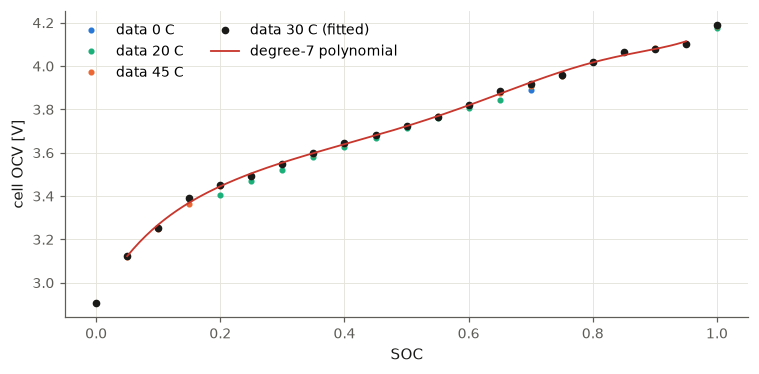

  2 s pulses: mean drift correction 0.108 mOhm (0.3 % of DCIR)
180 s pulses: mean drift correction 9.750 mOhm (15.1 % of DCIR)


In [21]:
refit = cells.fit_ocv_polynomial(s30, v30)
print("refit   :", np.round(refit, 6))
print("built-in:", np.round(ocv.coefficients, 6))
check("OCV refit reproduces the built-in coefficients (rtol 1e-6)", np.allclose(refit, ocv.coefficients, rtol=1e-6, atol=0))
res_V = ocv.voltage_V(s30) - v30
print(f"residuals: rms {np.sqrt(np.mean(res_V**2))*1e3:.1f} mV, max {np.max(np.abs(res_V))*1e3:.1f} mV")
check("OCV fit rms 9 mV, max 21 mV (docstring L159-160)",
      abs(np.sqrt(np.mean(res_V**2)) - 0.009) < 0.0005 and abs(np.max(np.abs(res_V)) - 0.021) < 0.0005)
fig, ax = plt.subplots(figsize=(7, 3.5))
for t_C, color in ((0.0, blue), (20.0, aqua), (45.0, orange)):
    s_, v_ = ocv_table.at_temperature(t_C)
    ax.plot(s_, v_, "o", ms=3, color=color, label=f"data {t_C:g} C")
ax.plot(s30, v30, "o", ms=4, color=ink, label="data 30 C (fitted)")
ax.plot(soc_grid, ocv.voltage_V(soc_grid), color=red, lw=1.2, label="degree-7 polynomial")
ax.set_xlabel("SOC"); ax.set_ylabel("cell OCV [V]"); ax.legend(ncol=2); plt.tight_layout(); plt.show()
drift = cells.resistance_dc_corrected_ohm(dcir.select(True), ocv, cell.capacity_As)
raw = dcir.select(True).resistance_dc_ohm
for t in (2, 180):
    m = dcir.select(True).duration_pulse_s == t
    print(f"{t:>3} s pulses: mean drift correction {np.mean(raw[m] - drift[m])*1e3:.3f} mOhm "
          f"({np.mean(1 - drift[m]/raw[m])*100:.1f} % of DCIR)")

In [22]:
show_source("src/aircraft_closure/powertrain/cells.py", 115, 169)

# src/aircraft_closure/powertrain/cells.py  lines 115-169
 115  def fit_resistance_model(dcir=None, ocv_model=None, capacity_cell_As=4.9 * 3600, time_constants_s=(8.0, 43.0),
 116                           temperature_reference_C=25.0, initial=None):
 117      """Global least squares (relative residuals) of `CellResistanceModel.resistance_dc_ohm` to discharge DCIR.
 118  
 119      R1 shares R0's temperature exponents and has no SOC term (the 2-180 s pulses do not resolve more).
 120      Returns (model, relative residuals).
 121      """
 122      dcir = (dcir if dcir is not None else load_dcir_table()).select(discharge=True)
 123      ocv_model = ocv_model if ocv_model is not None else inr21700_50g_cell().ocv_model
 124      target_ohm = resistance_dc_corrected_ohm(dcir, ocv_model, capacity_cell_As)
 125      start = initial if initial is not None else inr21700_50g_cell().resistance_model
 126      b0, b1, b2 = start.branches
 127      opti = asb.Opti()
 128      r0 = opti.variable(i

### 3.3 The resistance fit (L115-155) and pulse power (L158-160)

- **L115-121** signature: capacity and time constants (8 s, 43 s, the Fig. 12 25 C values) are **inputs**, not
  fitted: a free per-point RC split was ill-conditioned (`021`).
- **L122-125** discharge points only, OCV-drift-corrected target, start from the built-in model (`initial`).
- **L127-139** one `asb.Opti`, 13 variables:
  - R0, R1, R2 with `scale` at their magnitude (10 and 1 mOhm) and `lower_bound=0`;
  - a0, q0 (R0 and R1 temperature), a2, q2 (R2 temperature): unbounded;
  - c0, d0, c2, d2 (SOC rise coefficients) in −1..10;
  - the two SOC widths in 0.01..0.5.
- **L140-144** builds a `CellResistanceModel` whose fields **are Opti variables**: the same class as the component,
  so the fit uses exactly the production equations. R1 shares a0, q0 and has no SOC terms (L142).
- **L145** relative residual: model DCIR / target − 1. Relative because DCIR varies several-fold over −10..45 C, and
  absolute residuals would fit mainly the cold data.
- **L146-147** minimize the sum of squares; IPOPT. **L148-155** rebuild with numbers; return the model and the
  residual vector.
- **L158-160 `pulse_power_W`**: Paudel eq. 12 / DOE HPPC, P = V_min·(OCV − V_min)/R: the power at which the terminal
  voltage just reaches 2.5 V. Used in the test cross-check of the two digitizations and above in section 2.5.

**Run it: refit the resistance model and compare all 13 coefficients**, from the built-in start and from a
deliberately perturbed start (×1.5 resistances, halved linear exponents, zeroed quadratics, other SOC terms and
widths), to show the fit is not merely returning its initial guess.

In [23]:
import time
t0 = time.perf_counter()
fitted, residual = cells.fit_resistance_model()
print(f"fit in {time.perf_counter()-t0:.2f} s: rms {np.sqrt(np.mean(residual**2))*100:.2f} %, "
      f"max {np.max(np.abs(residual))*100:.1f} % over {len(residual)} points")

def coefficients(model):
    out = {}
    for k, b in enumerate(model.branches):
        out.update({f"R{k}_ref": b.resistance_ref_ohm, f"a{k}": b.exponent_temperature_linear,
                    f"b{k}": b.exponent_temperature_quadratic, f"c{k}": b.coefficient_soc_low, f"d{k}": b.coefficient_soc_high})
    out.update(w_lo=model.width_soc_low, w_hi=model.width_soc_high)
    return out

built_in = coefficients(rm)
perturbed = replace(rm, branches=tuple(replace(b, resistance_ref_ohm=1.5 * b.resistance_ref_ohm,
                                               exponent_temperature_linear=0.5 * b.exponent_temperature_linear,
                                               exponent_temperature_quadratic=0.0, coefficient_soc_low=0.5,
                                               coefficient_soc_high=0.5) for b in rm.branches),
                    width_soc_low=0.15, width_soc_high=0.1)
fitted_cold, _ = cells.fit_resistance_model(initial=perturbed)
print(f"{'coef':<7}{'built-in':>14}{'refit':>14}{'refit (perturbed start)':>26}")
for k, v in built_in.items():
    print(f"{k:<7}{v:>14.6g}{coefficients(fitted)[k]:>14.6g}{coefficients(fitted_cold)[k]:>26.6g}")
check("resistance refit reproduces all built-in coefficients (rel 1e-6, abs 1e-9)",
      all(abs(coefficients(fitted)[k] - v) <= 1e-6 * abs(v) + 1e-9 for k, v in built_in.items()))
check("same optimum from a perturbed start (rel 1e-6, abs 1e-9)",
      all(abs(coefficients(fitted_cold)[k] - v) <= 1e-6 * abs(v) + 1e-9 for k, v in built_in.items()))
check("fit quality as documented: rms 4.7 %, max 21 %",
      abs(np.sqrt(np.mean(residual**2)) - 0.047) < 0.001 and abs(np.max(np.abs(residual)) - 0.21) < 0.01)

fit in 0.04 s: rms 4.71 %, max 20.6 % over 308 points


coef         built-in         refit   refit (perturbed start)
R0_ref      0.0239244     0.0239244                 0.0239244
a0            3.72709       3.72709                   3.72709
b0            38.8291       38.8291                   38.8291
c0          0.0412081     0.0412081                 0.0412081
d0           0.039283      0.039283                  0.039283
R1_ref     0.00178812    0.00178812                0.00178812
a1            3.72709       3.72709                   3.72709
b1            38.8291       38.8291                   38.8291
c1                  0             0                         0
d1                  0             0                         0
R2_ref      0.0157512     0.0157512                 0.0157512
a2            6.53713       6.53713                   6.53713
b2           -22.0354      -22.0354                  -22.0354
c2           0.947575      0.947575                  0.947575
d2           0.267037      0.267037                  0.267037
w_lo    

**Model vs data** at two temperatures, short and long pulses. The 180 s DCIR is above the 2 s DCIR at every SOC:
that gap is the RC polarization the time constants represent.

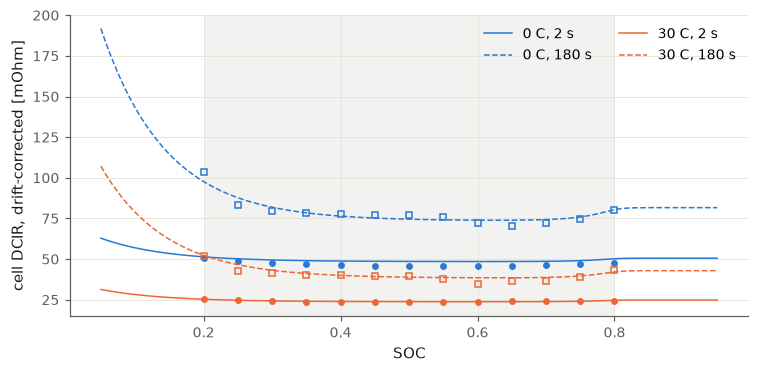

In [24]:
d = dcir.select(True)
target = cells.resistance_dc_corrected_ohm(d, ocv, cell.capacity_As)
fig, ax = plt.subplots(figsize=(7, 3.5))
for t_C, color in ((0.0, blue), (30.0, orange)):
    for t_s, marker in ((2.0, "o"), (180.0, "s")):
        m = (d.temperature_C == t_C) & (d.duration_pulse_s == t_s)
        ax.plot(d.soc[m], target[m] * 1e3, marker, ms=3.5, color=color, mfc="none" if t_s == 180 else color)
        ax.plot(soc_grid, rm.resistance_dc_ohm(soc_grid, t_C, t_s) * 1e3, color=color,
                ls="-" if t_s == 2 else "--", lw=1, label=f"{t_C:g} C, {t_s:g} s")
ax.axvspan(0.2, 0.8, color=ink_muted, alpha=0.08, lw=0)
ax.set_xlabel("SOC"); ax.set_ylabel("cell DCIR, drift-corrected [mOhm]"); ax.legend(ncol=2); plt.tight_layout(); plt.show()

**The unused Fig. 12 table vs the fixed time constants.** `load_ecm_table` is never called. Its averages near 25 C
are the source quoted for tau = 8 s and 43 s; here is what the file says at 20 and 30 C.

In [25]:
for t_C in (20.0, 30.0):
    m = ecm.temperature_C == t_C
    print(f"{t_C:g} C: tau1 mean {np.nanmean(ecm.time_constant_1_s[m]):.1f} s, tau2 mean {np.nanmean(ecm.time_constant_2_s[m]):.1f} s, "
          f"R0 mean {np.nanmean(ecm.resistance_0_ohm[m])*1e3:.1f} mOhm (fit R0_ref {rm.branches[0].resistance_ref_ohm*1e3:.1f})")
m = (ecm.temperature_C == 20.0) | (ecm.temperature_C == 30.0)
check("fixed tau (8 s, 43 s) within 25 % of the Fig. 12 means at 20-30 C",
      abs(np.nanmean(ecm.time_constant_1_s[m]) / 8 - 1) < 0.25 and abs(np.nanmean(ecm.time_constant_2_s[m]) / 43 - 1) < 0.25)

20 C: tau1 mean 7.5 s, tau2 mean 45.1 s, R0 mean 27.3 mOhm (fit R0_ref 23.9)
30 C: tau1 mean 8.8 s, tau2 mean 41.7 s, R0 mean 17.7 mOhm (fit R0_ref 23.9)
PASS  fixed tau (8 s, 43 s) within 25 % of the Fig. 12 means at 20-30 C


**Gotchas (`cells.py`)**

- `fit_resistance_model` defaults `capacity_cell_As=4.9*3600` instead of reading the cell; change the cell and the
  drift correction silently uses the wrong capacity.
- The OCV has no temperature term; the 30 C curve is used at all temperatures (within about 35 mV above SOC 0.3,
  `021`). At 0 C and low SOC the data sit well below the polynomial (plot above).
- Charge DCIR (308 rows) is loaded but not fitted; discharge resistance is used for charging (`021` "Deferred").

---
## 4. How the sizing uses the pack

### 4.1 `examples/halo_sizing.py`: building the pack

In [26]:
show_source("examples/halo_sizing.py", 467, 483)
show_source("examples/halo_sizing.py", 975, 984)
show_source("examples/halo_sizing.py", 1188, 1193)

# examples/halo_sizing.py  lines 467-483
 467  def build_halo_battery(design, assumptions=HaloAssumptions()):
 468      a, d = assumptions, design
 469      if a.battery_model == "ecm":
 470          return EquivalentCircuitBattery(count_series=a.count_series_battery, count_parallel=d.count_parallel_battery,
 471                                          factor_power_density=a.factor_power_density_battery,
 472                                          temperature_cell_C=a.temperature_cell_battery_C,
 473                                          factor_capacity_ageing=a.factor_capacity_ageing_battery,
 474                                          factor_resistance_ageing=a.factor_resistance_ageing_battery,
 475                                          fraction_mass_cells=a.fraction_mass_cells_battery,
 476                                          min_soc=soc_emergency_floor, max_soc=soc_take_off, **battery_thermal(a))
 477      if a.battery_model == "constant":
 478          return Batte

- **L467-476 the ECM branch** (default `battery_model="ecm"`): N_s = 210 (Python int), N_p =
  `design.count_parallel_battery` (an Opti variable, L1125-1126: init from `count_parallel_guess`, `scale=10`,
  `lower_bound=1`), F = 5, 25 C, ageing 0.8 / 1.5, cell fraction 0.7, SOC window 0.10..0.95 (the emergency floor
  and the take-off SOC, module constants L89-91), and the thermal model if on.
- **L477-482 the constant branch**: energy and discharge power are **two** Opti variables (L1121-1124); R = 1.8e6 /
  E; charge power = half the discharge; mass smoothing 10 kg. It is used by legacy sets (`assumptions_tier16` and
  earlier) and as the **"constant_battery" warm start** of the ECM problem (`_precursor_problem` L1684-1685: solve
  the constant-battery problem at minimum mass, then start the ECM from it).
- **L975-984 `count_parallel_guess`**: the bridge between the two. From a constant-battery start, build a single
  ECM string (N_p = 1) and divide energies: N_p0 = E_guess / E_string, so the ECM starts with the same energy.
- **L1188-1193**: with the ECM, `design` gets the pack's energy and rated power **as expressions** of N_p, so every
  downstream consumer that reads `design.energy_capacity_battery_J` (hot-day SOC, ground recharge energy) works for
  both models.

In [27]:
one_string = build_halo_battery(replace(ref.design, count_parallel_battery=1.0), assumptions)
check("count_parallel_guess energy-matches: E(pack) / E(one string) = count_parallel",
      abs(pack.energy_capacity_J / one_string.energy_capacity_J - pack.count_parallel) < 1e-9)
print(f"constant pack built from the same E/P: mass {constant.get_mass():.0f} kg vs ECM {pack.get_mass():.0f} kg "
      f"(constant: 250 Wh/kg, ECM: {pack.energy_capacity_J/3.6e3/pack.get_mass():.0f} Wh/kg at end of life)")

PASS  count_parallel_guess energy-matches: E(pack) / E(one string) = count_parallel
constant pack built from the same E/P: mass 289 kg vs ECM 475 kg (constant: 250 Wh/kg, ECM: 147 Wh/kg at end of life)


### 4.2 `performance/flight_point.py`: one call per point, plus the root-selection constraint

In [28]:
show_source("src/aircraft_closure/performance/flight_point.py", 234, 243)

# src/aircraft_closure/performance/flight_point.py  lines 234-243
 234      # With cooling (Tier 19) start at zero current: 50 A held through a long cruise drives the coulomb-counted SOC
 235      # chain far outside the cell data, and the battery loss there, through the exchanger's cubic pumping law,
 236      # swamps IPOPT. Without cooling the earlier 50 A start is kept (reference results unchanged).
 237      current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0, scale=100.0)
 238      if isinstance(battery_model, EquivalentCircuitBattery):
 239          battery = battery_model.evaluate(current_battery_A, condition.soc, duration_s, voltage_rc_start_V)
 240          # Low-current root of R_eff I^2 - V* I + P = 0; also P <= V*^2 / (4 R_eff).
 241          opti.subject_to(battery.voltage_V / battery.voltage_driving_V >= 0.5)
 242      else:
 243          battery = battery_model.evaluate(current_battery_A, condition.soc)


- **L237** the battery current is an Opti variable per point, `scale=100` A. Initial guess 0 A with cooling installed
  (the comment: 50 A held through a long cruise drives the coulomb-counted SOC chain outside the cell data), else
  50 A.
- **L239** `evaluate(I, soc, duration_s, voltage_rc_start_V)`: temperature not passed, so the pack's 25 C is used.
  `condition.soc` is the start SOC of the point (an expression chained by the mission).
- **L241 `V / V* ≥ 0.5`**: the branch constraint. Written as a ratio so it is O(1) for IPOPT whatever the pack voltage.
  Nothing else ties I to the power: the bus power balance (L388-391) fixes V·I = h_e × demand, and that quadratic has
  two roots.
- **L243** the constant battery is evaluated with zero duration (its SOC is updated by the mission).
- The battery's terminal voltage is the bus voltage (L263), or minus the feeder/string contactor drop (L256-261).
  The Halo has strings (redundancy on), so `voltage_feeder_battery_V = V − I·R_string/2`.

**Run it: the two roots.** Same power and state as engine-out point 1/3. Without the branch constraint IPOPT started
at a high current lands on the high root; with it, from the same start, IPOPT declares the problem infeasible
(`021` "Root selection": restoration stalls at the power peak). From the low side it returns the sized point.

In [29]:
P = row["power_W"]
def solve_root(guess, branch):
    opti = asb.Opti(); I = opti.variable(init_guess=guess, scale=100.0)
    r = pack.evaluate(I, row["soc_start"], row["duration_s"], None)
    opti.subject_to(r.power_electric_W / 1e5 == P / 1e5)
    if branch:
        opti.subject_to(r.voltage_V / r.voltage_driving_V >= 0.5)
    try:
        sol = opti.solve(verbose=False)
        return sol.value(I), sol.value(r.voltage_V / r.voltage_driving_V)
    except RuntimeError:
        return None, None
low, high, blocked = solve_root(900.0, True), solve_root(3000.0, False), solve_root(3000.0, True)
print(f"low root  : I = {low[0]:.1f} A, V/V* = {low[1]:.3f}")
print(f"high root : I = {high[0]:.1f} A, V/V* = {high[1]:.3f}  (no branch constraint)")
print(f"high start with the constraint: {'infeasible' if blocked[0] is None else blocked}")
check("low root reproduces the sized engine-out current", abs(low[0] - row["current_A"]) < 1e-3)
check("high root has V/V* < 0.5 and the constraint excludes it", high[1] < 0.5 and blocked[0] is None)

low root  : I = 990.8 A, V/V* = 0.820
high root : I = 3411.1 A, V/V* = 0.244  (no branch constraint)
high start with the constraint: infeasible
PASS  low root reproduces the sized engine-out current
PASS  high root has V/V* < 0.5 and the constraint excludes it


### 4.3 `mission/mission.py`: SOC and RC chaining

In [30]:
show_source("src/aircraft_closure/mission/mission.py", 75, 96)
show_source("src/aircraft_closure/mission/mission.py", 102, 132)

# src/aircraft_closure/mission/mission.py  lines 75-96
  75      battery = aircraft.powertrain.topology.instances["battery"].component
  76      is_ecm = isinstance(battery, EquivalentCircuitBattery)
  77      counts = subsegments if isinstance(subsegments, tuple) else (subsegments,) * len(mission.segments)
  78      if len(counts) != len(mission.segments) or any(n < 1 for n in counts):
  79          raise ValueError("subsegments needs one count >= 1 per segment.")
  80      if polarization_start not in ("rest", "steady"):
  81          raise ValueError(f"Unknown polarization_start '{polarization_start}'.")
  82      if isinstance(thermal_start, dict):
  83          temperatures_C = dict(thermal_start)
  84      elif thermal_start == "coolant":
  85          temperatures_C = coolant_temperatures_C(aircraft.powertrain)
  86      elif thermal_start == "steady":
  87          temperatures_C = None
  88      else:
  89          raise ValueError(f"Unknown thermal_start '{thermal_start}'.")


- **L75-76** the pack type decides the path (`isinstance`, not a flag).
- **L80-81** `polarization_start` must be "rest" or "steady".
- **L90-91** the initial RC state: "rest" → (0.0, 0.0) (one zero per RC branch, from the cell's time constants);
  "steady" → `None`, which the first `evaluate` treats as steady state.
- **L96** equal sub-segment durations (the cruise duration is symbolic, so is each piece).
- **L102-106** ECM: pass `duration_s` and the running RC state.
- **L117-121 ECM path**: SOC end = `point.battery.soc_next` (coulomb counting inside the battery); RC state for the
  next point = `voltage_rc_end_V`; one margin per point: end-of-interval voltage ≥ N_s × 2.5 V.
- **L122-125 constant path**: SOC from chemical energy / capacity (degraded capacity if a string is out).
- **L126** SOC window at every point end: ≤ max_soc, ≥ `soc_floor` (or min_soc).
- **L116** chemical energy = P_chem × dt for both models; for the ECM it equals N_s·Q·OCV(s_mid)·Δs.

In `halo_sizing.py`: the mission starts at SOC 0.95 with `polarization_start="rest"` (the default) and
sub-segments (1, 1, 4, 1, 1, 1) (L1195-1199); the engine-out hover starts at `soc_reserve` = 0.30 with
`polarization_start="steady"` (the engine fails while the pack is already loaded) and 3 sub-segments
(L1213-1221); the failure hovers do the same (L1440-1445).

**Run it: replay the sized mission and the engine-out hover** from the stored currents with only
`EquivalentCircuitBattery.evaluate` and the chaining rule of L117-119. Every SOC, mean voltage and end voltage
reproduces the solved values to round-off: the trace in the result is exactly this model.

In [31]:
def replay(trace, rc_start):
    worst, rc, soc = 0.0, rc_start, trace[0]["soc_start"]
    for r in trace:
        b = pack.evaluate(r["current_A"], soc, r["duration_s"], rc)
        worst = max(worst, abs(b.soc_next - r["soc_end"]), abs(b.voltage_V - r["voltage_bus_V"]) / 1e3,
                    abs(b.voltage_end_V - r["voltage_end_V"]) / 1e3)
        rc, soc = b.voltage_rc_end_V, b.soc_next
    return worst
print(f"{'point':<22}{'dt [s]':>8}{'SOC0':>7}{'SOC1':>7}{'I [A]':>8}{'OCV':>7}{'V':>7}{'V_end':>7}")
for r in ref.battery_trace + ref.engine_out_trace:
    print(f"{r['label']:<22}{r['duration_s']:>8.0f}{r['soc_start']:>7.3f}{r['soc_end']:>7.3f}{r['current_A']:>8.1f}"
          f"{r['voltage_ocv_V']:>7.1f}{r['voltage_bus_V']:>7.1f}{r['voltage_end_V']:>7.1f}")
check("mission replay (rest start, RC chained) reproduces the solved trace", replay(ref.battery_trace, (0.0, 0.0)) < 1e-9)
check("engine-out replay (steady start) reproduces the solved trace", replay(ref.engine_out_trace, None) < 1e-9)
check("engine-out end voltage is the binding 525 V limit",
      abs(ref.engine_out_trace[-1]["voltage_end_V"] - 525.0) < 1e-4
      and "engine-out hover 3/3: battery end voltage_V" in ref.binding)

point                   dt [s]   SOC0   SOC1   I [A]    OCV      V  V_end
take-off hover              60  0.950  0.928   117.1  862.1  850.6  848.7
climb                      508  0.928  0.756   109.9  849.6  835.7  835.6
cruise 1/4                2158  0.756  0.815    -8.8  841.2  842.1  842.3
cruise 2/4                2158  0.815  0.785     4.5  843.6  843.0  843.0
cruise 3/4                2158  0.785  0.658    19.0  828.9  826.7  826.7
cruise 4/4                2158  0.658  0.471    28.1  794.6  791.3  791.3
reserve loiter            1200  0.471  0.527   -15.0  781.6  783.3  783.4
descent                    610  0.527  0.466    32.3  781.1  777.6  777.4
landing hover               60  0.466  0.435   169.2  772.9  756.6  754.7
engine-out hover 1/3        20  0.300  0.239   990.8  740.3  606.8  606.8
engine-out hover 2/3        20  0.239  0.175  1030.2  725.5  583.7  579.9
engine-out hover 3/3        20  0.175  0.106  1122.6  704.2  536.2  525.0
PASS  mission replay (rest start, RC c

**Run it: why N_p = 22.95.** A tiny `asb.Opti` with only the pack: N_p is a variable, the three engine-out points
hold the solved terminal powers, chained with steady start, subject to the branch constraint, the current rating,
the end-voltage limit and the SOC floor. Minimizing N_p returns the sized value: the pack is sized by the end
voltage of the engine-out hover (the binding margin), nothing else.

In [32]:
opti = asb.Opti()
n_p = opti.variable(init_guess=30.0, scale=10.0, lower_bound=1.0)
trial = replace(pack, count_parallel=n_p)
soc_, rc_, end_voltages = 0.30, None, []
for r in ref.engine_out_trace:
    I = opti.variable(init_guess=r["current_A"], scale=100.0)
    b = trial.evaluate(I, soc_, r["duration_s"], rc_)
    opti.subject_to([b.power_electric_W / 1e5 == r["power_W"] / 1e5, b.voltage_V / b.voltage_driving_V >= 0.5,
                     I <= trial.get_limits().max_discharge_current_A, b.soc_next >= 0.10,
                     b.voltage_end_V >= trial.get_limits().min_voltage_V])
    soc_, rc_ = b.soc_next, b.voltage_rc_end_V
    end_voltages.append(b.voltage_end_V)
opti.minimize(n_p)
sol = opti.solve(verbose=False)
print(f"minimum N_p = {sol.value(n_p):.6f} (sized {pack.count_parallel:.6f}); end voltages "
      + ", ".join(f"{sol.value(v):.1f}" for v in end_voltages) + f"; SOC end {sol.value(soc_):.4f}")
check("pack-only problem reproduces the sized count_parallel", abs(sol.value(n_p) / pack.count_parallel - 1) < 1e-6)

minimum N_p = 22.952682 (sized 22.952682); end voltages 606.8, 579.9, 525.0; SOC end 0.1059
PASS  pack-only problem reproduces the sized count_parallel


### 4.4 The hot-day hover: a second SOC accounting

In [33]:
show_source("examples/halo_sizing.py", 1236, 1246)

# examples/halo_sizing.py  lines 1236-1246
1236      hover_hot = None
1237      if r.hover_hot_day:
1238          hover_hot = build_flight_point(opti, aircraft, aerodynamics, FlightCondition(
1239              mode="hover", altitude_m=r.altitude_hover_hot_m, thrust_to_weight=r.thrust_to_weight_hover_hot,
1240              soc=flown.soc_end, temperature_offset_K=temperature_offset_K(r.altitude_hover_hot_m,
1241                                                                           r.temperature_hover_hot_K),
1242              label="hot-day hover"), flown.mass_end_kg,
1243              **(dict(duration_s=r.duration_hover_hot_s, temperature_start_C=flown.temperatures_end_C) if thermal
1244                 else {}))
1245          soc_after_hover_hot = flown.soc_end - (hover_hot.battery.power_chemical_W * r.duration_hover_hot_s
1246                                                 / design.energy_capacity_battery_J)


**L1245-1246** computes the SOC after the hot-day hover as chemical energy / `design.energy_capacity_battery_J`. For
the ECM that divides OCV(s_mid)·I·dt by the energy at the **mean** OCV over 0..1, which is not coulomb counting. The
point's own `battery.soc_next` (coulomb counting) is ignored. At SOC 0.43 the OCV is below the 0..1 mean, so the
energy formula under-counts the SOC drop. Same for the constant-battery engine-out branch (L1233-1234), where it is
correct because the OCV is constant there. Measured on the sized point:

In [34]:
hot = next(h for h in ref.hovers if h.label == "hot-day hover")
opti = asb.Opti(); I = opti.variable(init_guess=400.0, scale=100.0)
b = pack.evaluate(I, hot.soc, 60.0, None)
opti.subject_to([b.power_electric_W / 1e5 == hot.power_battery_W / 1e5, b.voltage_V / b.voltage_driving_V >= 0.5])
sol = opti.solve(verbose=False)
drop_energy = sol.value(b.power_chemical_W) * 60.0 / pack.energy_capacity_J
drop_coulomb = hot.soc - sol.value(b.soc_next)
print(f"hot-day hover: I = {sol.value(I):.1f} A; SOC drop by energy (code) {drop_energy:.5f}, by coulombs {drop_coulomb:.5f}; "
      f"reported SOC after {ref.soc_after_hover_hot:.4f} vs coulomb {hot.soc - drop_coulomb:.4f}")
check("reported hot-day SOC uses the energy formula", abs((hot.soc - drop_energy) - ref.soc_after_hover_hot) < 1e-9)
check("energy formula under-counts the SOC drop by about 2 % here (non-binding: floor 0.10)",
      0.01 < drop_coulomb / drop_energy - 1 < 0.03)

hot-day hover: I = 445.2 A; SOC drop by energy (code) 0.08090, by coulombs 0.08246; reported SOC after 0.3537 vs coulomb 0.3521
PASS  reported hot-day SOC uses the energy formula
PASS  energy formula under-counts the SOC drop by about 2 % here (non-binding: floor 0.10)


### 4.5 The end voltage is computed at the mid-interval OCV

`voltage_end_V` (L298) uses OCV(s_mid) and R0(s_mid). On the binding engine-out point 3/3 the SOC falls 0.069 in
20 s: the OCV at the end SOC is 15 V lower than at the mid SOC, and R0 is higher there:

In [35]:
last = ref.engine_out_trace[-1]
s_mid = (last["soc_start"] + last["soc_end"]) / 2
ocv_mid, ocv_end = pack.voltage_open_circuit_V(s_mid), pack.voltage_open_circuit_V(last["soc_end"])
r0_mid, r0_end = pack.resistances_ohm(s_mid)[0], pack.resistances_ohm(last["soc_end"])[0]
end_true = last["voltage_end_V"] - (ocv_mid - ocv_end) - last["current_A"] * (r0_end - r0_mid)
print(f"OCV mid {ocv_mid:.1f} V, OCV end {ocv_end:.1f} V; reported end V {last['voltage_end_V']:.1f} V, "
      f"with end-SOC OCV and R0 {end_true:.1f} V (RC end voltages unchanged)")
check("end voltage overestimated by more than 10 V at the binding point", last["voltage_end_V"] - end_true > 10)

OCV mid 704.2 V, OCV end 689.3 V; reported end V 525.0 V, with end-SOC OCV and R0 507.6 V (RC end voltages unchanged)
PASS  end voltage overestimated by more than 10 V at the binding point


---
## Findings

1. **`voltage_end_V` is not the end-of-interval voltage** (`battery_ecm.py` L298; field comment L203 "terminal
   voltage at the end of the interval"). It uses OCV and R0 at the mid-interval SOC. On the binding engine-out point
   3/3 it reports 525.0 V while OCV(s_end) and R0(s_end) give 507.6 V (section 4.5). The binding margin
   `engine-out hover 3/3: battery end voltage_V` is therefore optimistic by 17 V (3.3 %), and the pack is
   undersized for that constraint. Fix: evaluate OCV and R0 at `soc_next` in L298 (both are cheap expressions).
2. **Hot-day SOC uses energy, not coulombs, with the ECM** (`examples/halo_sizing.py` L1245-1246). It ignores the
   point's `battery.soc_next` and divides OCV(s_mid)·I·dt by the 0..1-mean-OCV energy. On the sized point it
   under-counts the SOC drop by about 2 % (section 4.4). Not binding today (0.354 vs floor 0.10). The ECM
   engine-out path does it right (via `build_mission`).
3. **`load_ecm_table` / `EcmTable` are unused** (`cells.py` L61-69, L89-92): no caller in `src/`, `examples/` or
   `tests/`. The time constants they would justify are hard-coded (8 s, 43 s, `battery_ecm.py` L175-176).
4. **Module docstring partly contradicts the code** (`battery_ecm.py` L38-40): "the resistance SOC terms continue
   exponentially". Only the low-SOC term does; the high-SOC term is held above 0.8 by `softmin` (L125-127,
   checked in 2.3). The class-level comment at L125 is correct.
5. **`fit_resistance_model` hard-codes the cell capacity** (`cells.py` L115, `capacity_cell_As=4.9 * 3600`) instead of
   `inr21700_50g_cell().capacity_As`, while it does read the OCV model from the cell (L123).
6. **The `fill_value=None` comment relies on CasADi behaviour** (`battery_ecm.py` L86): AeroSandbox documents None as
   "attempt to extrapolate"; the B-spline in fact holds the end values (checked in 2.2). The claim is true, the
   reason is not the one the argument documents.
7. Result fields `power_max_W`, `resistance_effective_ohm`, `voltage_rc_V` are read only by tests (diagnostics, not a
   bug).

## Limits / what it can't do

- One cell (Samsung 50G, NCA). Power density is an explicit scale factor F, not a cell trade.
- OCV has no temperature term; cell temperature does not feed back from the thermal model (`temperature_cell_C`
  stays 25 C, plan 028).
- Discharge resistance is used for charging; there is no 4.2 V charge limit at high SOC beyond the window margin.
- `count_parallel` is continuous; no integer strings, no module/pack-structure mass beyond the 0.7 fraction.
- No ageing model: end-of-life factors are fixed inputs (0.8, 1.5). No cycle-life cost.
- Constant current within each point; RC dynamics are exact only under that assumption.

## What's next (from `docs/decisions/021` "Deferred" and `022`)

- Charge-specific resistance and the 4.2 V charge limit (data already in `inr21700_50g_dcir.csv`).
- Cell temperature from the thermal model; OCV temperature dependence.
- Cycle-life cost and a depth-of-discharge ageing model.
- A requirement decision by the author on the reserve definition (SOC window, duration, end of life) and a cell
  trade.

## Review questions

<details><summary>Why is V ≥ V*/2 the right root-selection constraint, and what else does it enforce?</summary>

V·I = P with V = V* − R_eff·I gives R_eff·I² − V*·I + P = 0. The roots are symmetric around I = V*/(2 R_eff), where
V = V*/2 and P is maximal (V*²/4R_eff). The low-current root has V > V*/2. So V ≥ V*/2 picks the low root and, since
both roots merge at the vertex, also enforces P ≤ V*²/(4 R_eff). Without it IPOPT can converge to the high root
(I = 3,411 A, V/V* = 0.24 above).
</details>

<details><summary>What does `voltage_rc_start_V=None` mean, and when does the Halo use it?</summary>

No RC history: both branches at steady state I·R_k, so R_eff = R0 + R1 + R2 and V* = OCV. It is conservative for
pulses shorter than about 3·tau_2 (2 min). The Halo uses it for the engine-out and failure hovers
(`polarization_start="steady"`: the pack is already loaded when the engine fails) and for the requirement and
hot-day hover points. The mission starts from rest (0, 0) and chains `voltage_rc_end_V`.
</details>

<details><summary>Why is SOC updated by coulomb counting in the ECM and by energy in the constant battery?</summary>

SOC is charge. With a constant OCV, energy / (OCV·Q) equals charge / Q, so the two agree. With OCV(SOC) they do
not: energy per unit SOC follows the OCV, which rises 26 % from SOC 0.10 to 0.95 (3.27 to 4.11 V per cell). The ECM counts coulombs (exact for constant current)
and evaluates OCV at the mid SOC so that the chemical energy OCV·I·dt is the midpoint rule of the exact integral.
</details>

<details><summary>How does F (power density) enter, and why does it not change mass?</summary>

Pack resistances are divided by F and current ratings multiplied by F (`resistances_ohm` L259, `get_limits`
L269-270); mass is cells × 69 g / 0.7. It is the author's explicit assumption (decision 2026-10-02): keep the 50G
discharge shape, make it as power-dense as needed. The `021` sweep shows the binding constraint moving from current
rating (F 2-3) to end voltage (F 5) to reserve energy (F ≥ 8).
</details>

<details><summary>How is the resistance model fitted, and why are the residuals relative?</summary>

One `asb.Opti` with 13 variables builds a `CellResistanceModel` whose fields are Opti variables and matches its
`resistance_dc_ohm` to all 308 discharge DCIR points after removing the OCV drift (dOCV/dSOC·t/Q). Time constants
are fixed at 8 and 43 s; R1 shares R0's temperature factor. Residuals are relative because DCIR spans an order of
magnitude across temperature: absolute residuals would fit the cold data and ignore the warm data. Result: 4.7 % rms,
21 % max; the refit reproduces the hard-coded literals to 1e-6.
</details>

<details><summary>What sizes the Halo pack, and how do you show it?</summary>

The end-of-interval voltage of engine-out hover point 3/3 (525 V = 210 × 2.5 V) is in the binding list. A pack-only
Opti that holds the three engine-out powers and minimizes N_p subject to the branch constraint, current rating,
end-voltage limit and SOC floor returns N_p = 22.95, the sized value. Given Finding 1, that end voltage is
evaluated at the mid-interval OCV and R0 and is 17 V optimistic.
</details>

In [36]:
check_summary()

52 of 52 checks passed
